# Personal Information
Name: **Brent Brakenhoff**

StudentID: **13068989**

Email: [**brakenhoff.brent@gmail.com**](brakenhoff.brent@gmail.com)

Submitted on: **23.03.2025**

# Data Context
**The dataset consists of two datasets from rijdendetreinen.nl, the services dataset from 2019-2024 and the disruption datasets from these same years. These datasets have been appended and transformed so we have a daily overview over wether a trajectory has been disrupted that day. Additionally, the daily weather data has been sourced from KNMI, for a few different weather stations. This has been merged with the daily trajectory dataset based on the closest weather station to the source of the trajectory.**

# Data Description

**Present here the results of your exploratory data analysis. Note that there is no need to have a "story line" - it is more important that you show your understanding of the data and the methods that you will be using in your experiments (i.e. your methodology).**

**As an example, you could show data, label, or group balances, skewness, and basic characterizations of the data. Information about data frequency and distributions as well as results from reduction mechanisms such as PCA could be useful. Furthermore, indicate outliers and how/why you are taking them out of your samples, if you do so.**

**The idea is, that you conduct this analysis to a) understand the data better but b) also to verify the shapes of the distributions and whether they meet the assumptions of the methods that you will attempt to use. Finally, make good use of images, diagrams, and tables to showcase what information you have extracted from your data.**

As you can see, you are in a jupyter notebook environment here. This means that you should focus little on writing text and more on actually exploring your data. If you need to, you can use the amsmath environment in-line: $e=mc^2$ or also in separate equations such as here:

\begin{equation}
    e=mc^2 \mathrm{\space where \space} e,m,c\in \mathbb{R}
\end{equation}

Furthermore, you can insert images such as your data aggregation diagrams like this:

![image](example.png)

In [2]:
# Imports
import os
import numpy as np
import pandas as pd

### Data Loading

In [7]:
# Load your data here
disruptions_df = pd.read_csv('daily_disruptions_weather.csv')
disruptions_df

C:\Users\brake\AppData\Local\Temp\ipykernel_8916\2657719986.py:2: DtypeWarning: Columns (11,12,13,14,15,16,17,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  disruptions_df = pd.read_csv('daily_disruptions_weather.csv')


,Date,source,target,Rides planned,Final arrival delay,Final arrival cancelled,Completely cancelled,Intermediate arrival delays,Trajectory,Statistical Causes,...,RH,SQ,TG,TN,TX,RHX,VVX,T10N,FHVEC,Disrupted
0,2019-01-01,'s-Hertogenbosch,Arnhem Centraal,1,0,0,0,1,NaN,NaN,...,12,7,70,42,87,4,74,28,40,False
1,2019-01-01,'s-Hertogenbosch,Den Haag Centraal,33,4,2,0,27,NaN,NaN,...,12,7,70,42,87,4,74,28,40,False
2,2019-01-01,'s-Hertogenbosch,Deurne,17,4,1,0,11,NaN,NaN,...,12,7,70,42,87,4,74,28,40,False
3,2019-01-01,'s-Hertogenbosch,Dordrecht,11,0,0,0,3,NaN,NaN,...,12,7,70,42,87,4,74,28,40,False
4,2019-01-01,'s-Hertogenbosch,Eindhoven Centraal,18,2,0,0,7,NaN,NaN,...,12,7,70,42,87,4,74,28,40,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654431,2024-12-31,Zwolle,Nijmegen,1,0,0,0,1,NaN,NaN,...,-1.0,0.0,52.0,29.0,79.0,-1.0,80,29.0,82.0,False
654432,2024-12-31,Zwolle,Roosendaal,31,5,6,0,28,NaN,NaN,...,-1.0,0.0,52.0,29.0,79.0,-1.0,80,29.0,82.0,False
654433,2024-12-31,Zwolle,Schiphol Airport,1,0,0,0,0,NaN,NaN,...,-1.0,0.0,52.0,29.0,79.0,-1.0,80,29.0,82.0,False
654434,2024-12-31,Zwolle,Utrecht Centraal,29,1,0,0,19,NaN,NaN,...,-1.0,0.0,52.0,29.0,79.0,-1.0,80,29.0,82.0,False


### Analysis 1: 
Make sure to add some explanation of what you are doing in your code. This will help you and whoever will read this a lot in following your steps.

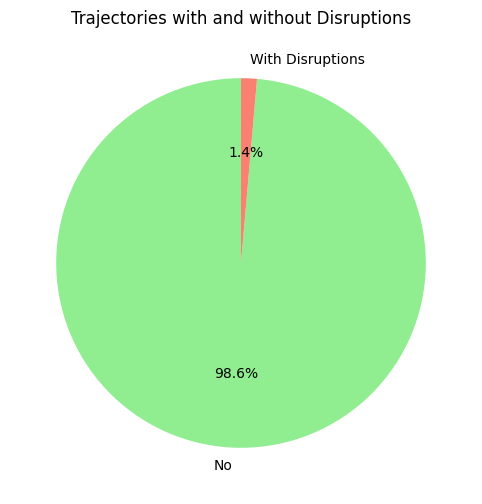

In [16]:
import matplotlib.pyplot as plt

# Count the number of trajectories with Disruption Count == 0 and > 0
disrupted = (disruptions_df["Disrupted"] == True).sum()
non_disrupted =  (disruptions_df["Disrupted"] == False).sum()

# Data for the pie chart
labels = ['No', 'With Disruptions']
sizes = [non_disrupted, disrupted]
colors = ['lightgreen', 'salmon']

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Trajectories with and without Disruptions')
plt.show()

### Analysis 2:

In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Strip column names to remove leading/trailing spaces
disruptions_df.columns = disruptions_df.columns.str.strip()

# Select weather-related features
weather_features = ['RH', 'SQ', 'TG', 'TN', 'TX', 'RHX', 'VVX', 'T10N', 'FHVEC']
weather_data = disruptions_df[weather_features].dropna()

# Clean the data: strip spaces and coerce non-numeric values to NaN
weather_data = weather_data.applymap(lambda x: str(x).strip() if isinstance(x, str) else x)
weather_data = weather_data.apply(pd.to_numeric, errors='coerce').dropna()
print(weather_data)
# Standardize the data
scaler = StandardScaler()
weather_data_scaled = scaler.fit_transform(weather_data)

# Add the 'Disrupted' column to the weather data for correlation analysis
weather_data['Disrupted'] = disruptions_df.loc[weather_data.index, 'Disrupted'].astype(int)

# Compute Pearson's correlation coefficients
correlation_matrix = weather_data.corr(method='pearson')

# Extract the correlation of weather features with the 'Disrupted' variable
disrupted_correlation = correlation_matrix['Disrupted'].drop('Disrupted')
print(disrupted_correlation)

C:\Users\brake\AppData\Local\Temp\ipykernel_8916\2757656434.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  weather_data = weather_data.applymap(lambda x: str(x).strip() if isinstance(x, str) else x)


          RH   SQ    TG    TN    TX  RHX   VVX  T10N  FHVEC
0       12.0  7.0  70.0  42.0  87.0  4.0  74.0  28.0   40.0
1       12.0  7.0  70.0  42.0  87.0  4.0  74.0  28.0   40.0
2       12.0  7.0  70.0  42.0  87.0  4.0  74.0  28.0   40.0
3       12.0  7.0  70.0  42.0  87.0  4.0  74.0  28.0   40.0
4       12.0  7.0  70.0  42.0  87.0  4.0  74.0  28.0   40.0
...      ...  ...   ...   ...   ...  ...   ...   ...    ...
654431  -1.0  0.0  52.0  29.0  79.0 -1.0  80.0  29.0   82.0
654432  -1.0  0.0  52.0  29.0  79.0 -1.0  80.0  29.0   82.0
654433  -1.0  0.0  52.0  29.0  79.0 -1.0  80.0  29.0   82.0
654434  -1.0  0.0  52.0  29.0  79.0 -1.0  80.0  29.0   82.0
654435  -1.0  0.0  52.0  29.0  79.0 -1.0  80.0  29.0   82.0

[608482 rows x 9 columns]
RH       0.001753
SQ       0.002168
TG       0.005772
TN       0.005055
TX       0.005820
RHX      0.001019
VVX      0.001325
T10N     0.003634
FHVEC    0.006470
Name: Disrupted, dtype: float64


### Analysis 3: 

### Analysis n:

In [5]:
# ...